In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import manifold_utils as mu
import importlib
from sklearn.manifold import TSNE

# Load the latest local classifier when rerunning this notebook.
importlib.reload(mu)

# Positive tolerance used by every classifier in this notebook.
FUZZ = 0.1

# Helper function to set equal aspect ratio in 3D
def set_equal_aspect_3d(ax, X):
    max_range = np.array([X[:,0].max()-X[:,0].min(), X[:,1].max()-X[:,1].min(), X[:,2].max()-X[:,2].min()]).max() / 2.0
    mid_x = (X[:,0].max()+X[:,0].min()) * 0.5
    mid_y = (X[:,1].max()+X[:,1].min()) * 0.5
    mid_z = (X[:,2].max()+X[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

Fuzz cutoff: 180 boundary candidates out of 952 points.


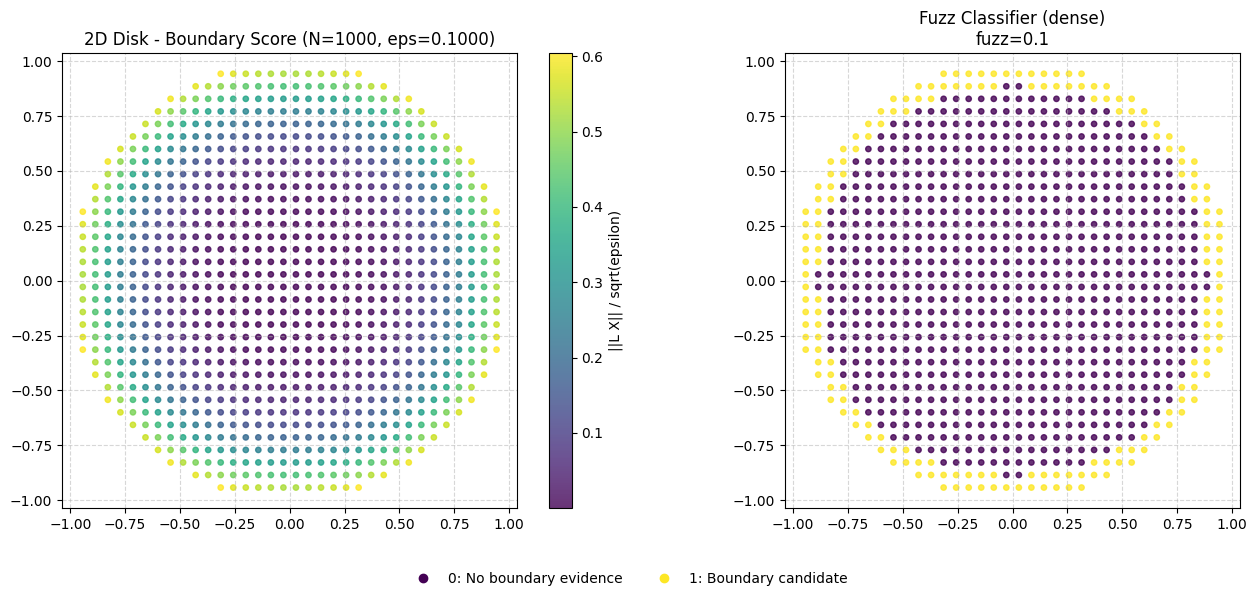

In [2]:
# 1. 2D Disk
N = 1000
eps = .1
X = mu.sample_disk(N=N, noise=0.0)
L = mu.compute_laplacian(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1)
sc1 = ax1.scatter(X[:, 0], X[:, 1], c=color_metric, cmap='viridis', s=15, alpha=0.8)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)')
ax1.set_title(f"2D Disk - Boundary Score (N={N}, eps={eps:.4f})")
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', alpha=0.5)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(X[:, 0], X[:, 1], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.8)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', alpha=0.5)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 190 boundary candidates out of 800 points.


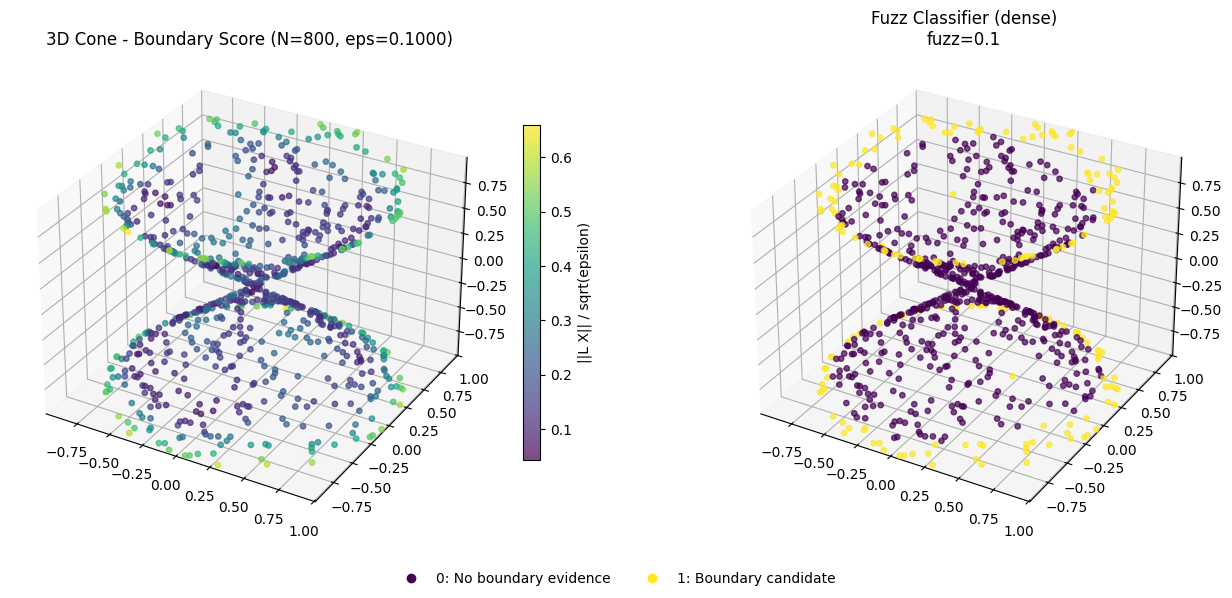

In [3]:
# 2. 3D Cone
N = 800
eps = 0.1
X = mu.sample_cone(N=N, noise=0.0)
L = mu.compute_laplacian(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_metric, cmap='viridis', s=15, alpha=0.7)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)', shrink=0.7)
ax1.set_title(f"3D Cone - Boundary Score (N={len(X)}, eps={eps:.4f})")
set_equal_aspect_3d(ax1, X)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.7)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
set_equal_aspect_3d(ax2, X)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 135 boundary candidates out of 800 points.


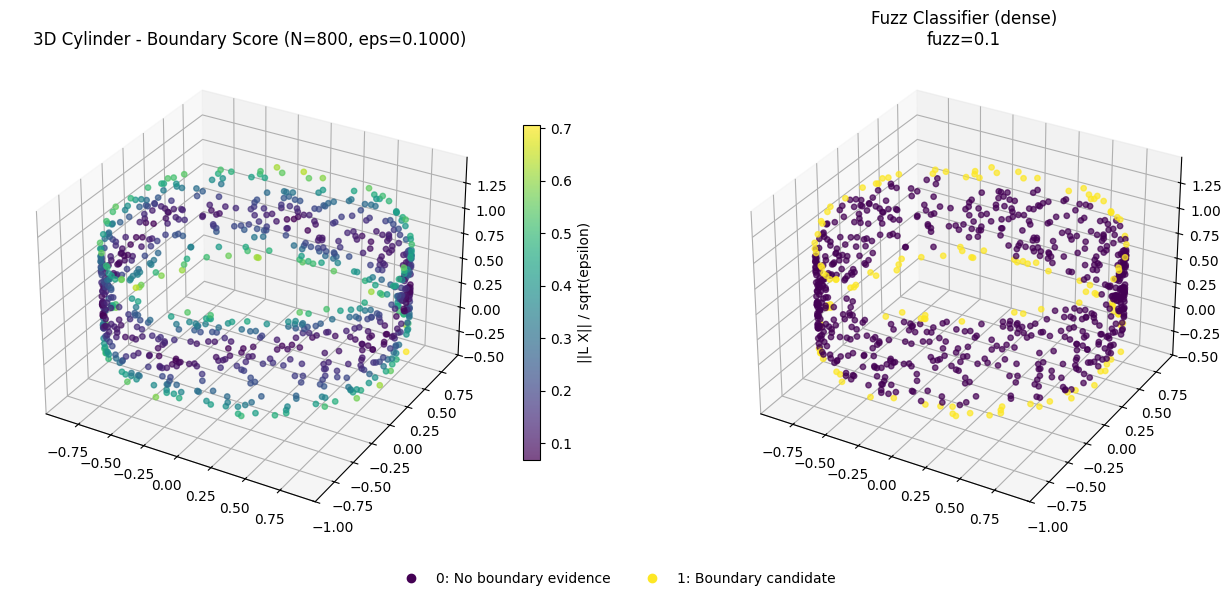

In [4]:
# 3. 3D Cylinder
N = 800
eps = 0.1
X = mu.sample_cylinder(N=N, noise=0.0)
L = mu.compute_laplacian(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_metric, cmap='viridis', s=15, alpha=0.7)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)', shrink=0.7)
ax1.set_title(f"3D Cylinder - Boundary Score (N={len(X)}, eps={eps:.4f})")
set_equal_aspect_3d(ax1, X)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.7)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
set_equal_aspect_3d(ax2, X)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 83 boundary candidates out of 1000 points.


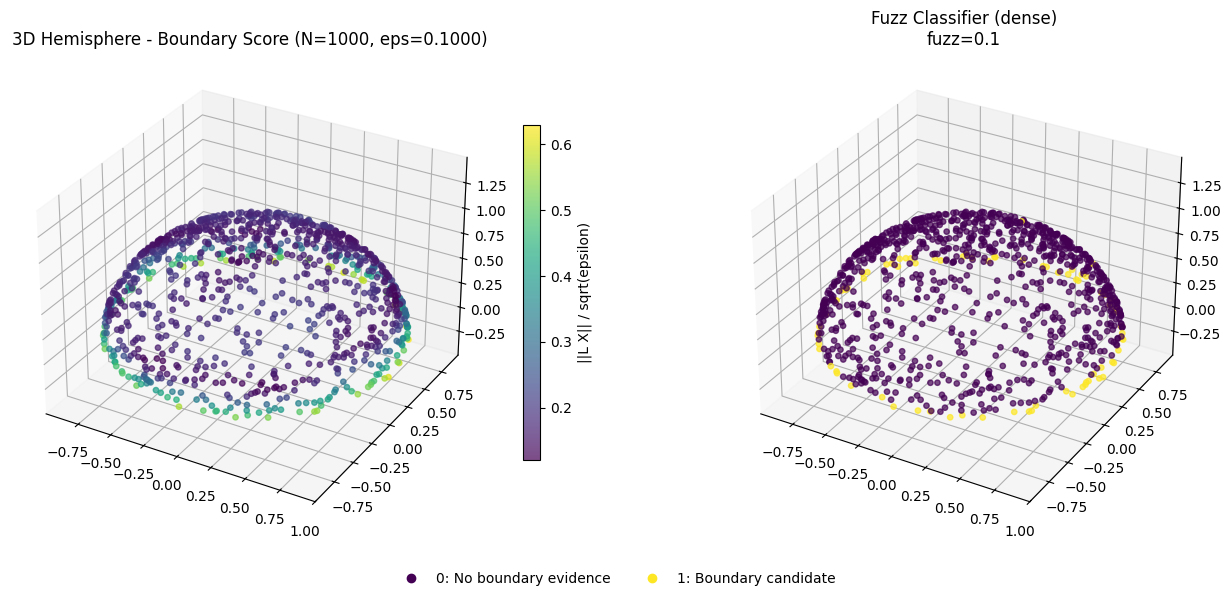

In [5]:
# 4. 3D Hemisphere
N = 1000
eps = 0.1
X = mu.sample_hemisphere(N=N, noise=0.)
L = mu.compute_laplacian(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_metric, cmap='viridis', s=15, alpha=0.7)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)', shrink=0.7)
ax1.set_title(f"3D Hemisphere - Boundary Score (N={len(X)}, eps={eps:.4f})")
set_equal_aspect_3d(ax1, X)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.7)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
set_equal_aspect_3d(ax2, X)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 0 boundary candidates out of 800 points.


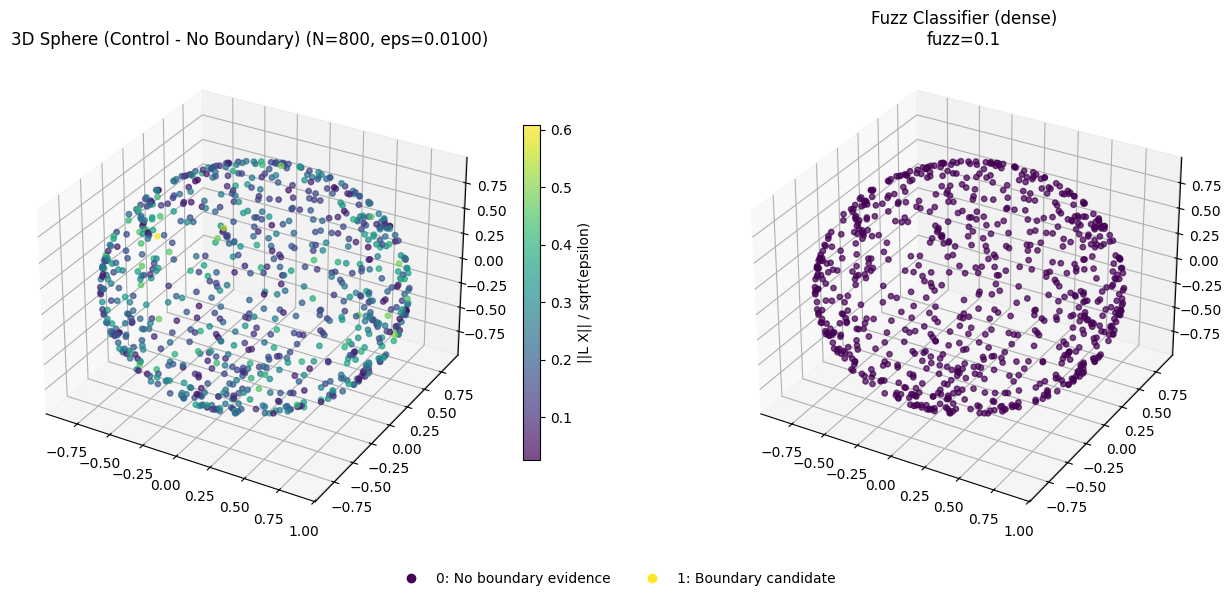

In [6]:
# 5. 3D Sphere (Control - No Boundary)
N = 800
eps = 0.01
X = mu.sample_sphere(N=N, noise=0.0)
L = mu.compute_laplacian(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_metric, cmap='viridis', s=15, alpha=0.7)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)', shrink=0.7)
ax1.set_title(f"3D Sphere (Control - No Boundary) (N={len(X)}, eps={eps:.4f})")
set_equal_aspect_3d(ax1, X)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.7)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
set_equal_aspect_3d(ax2, X)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 7 boundary candidates out of 200 points.


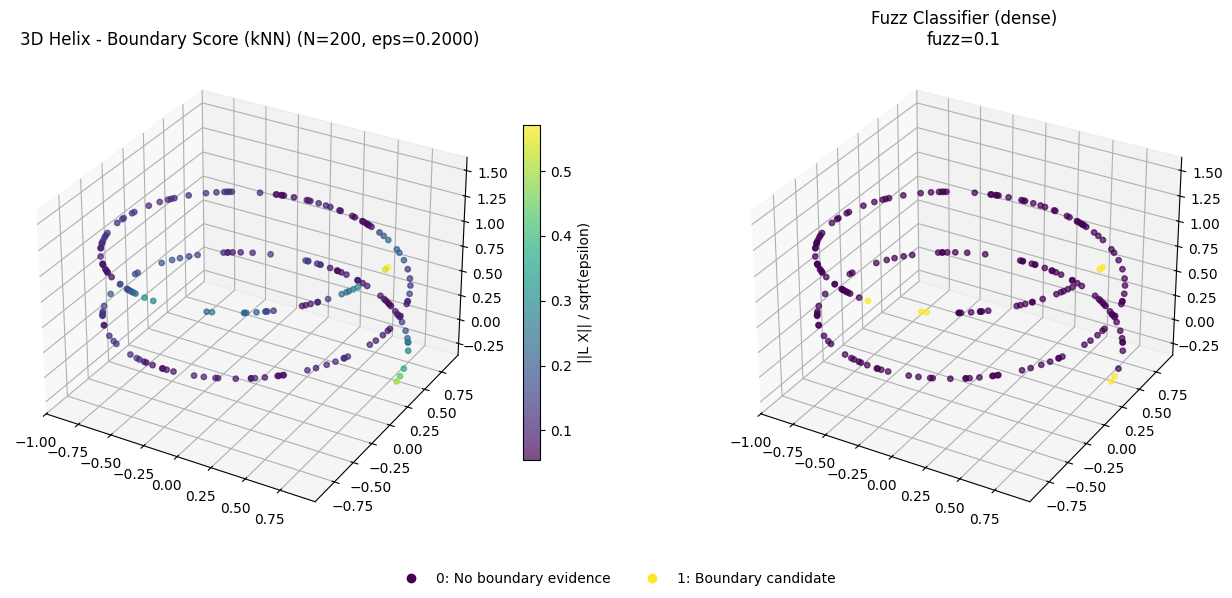

In [7]:
# 6. 3D Helix (1D Curve with Boundary)
N = 200
eps = 0.2
X = mu.sample_helix(N=N, noise=0.0)
L = mu.compute_laplacian_knn(X, eps, k =20)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Helper function to set equal aspect ratio in 3D
def set_equal_aspect_3d(ax, X):
    max_range = np.array([X[:,0].max()-X[:,0].min(), X[:,1].max()-X[:,1].min(), X[:,2].max()-X[:,2].min()]).max() / 2.0
    mid_x = (X[:,0].max()+X[:,0].min()) * 0.5
    mid_y = (X[:,1].max()+X[:,1].min()) * 0.5
    mid_z = (X[:,2].max()+X[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_metric, cmap='viridis', s=15, alpha=0.7)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)', shrink=0.7)
ax1.set_title(f"3D Helix - Boundary Score (kNN) (N={len(X)}, eps={eps:.4f})")
set_equal_aspect_3d(ax1, X)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.7)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
set_equal_aspect_3d(ax2, X)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 451 boundary candidates out of 1000 points.


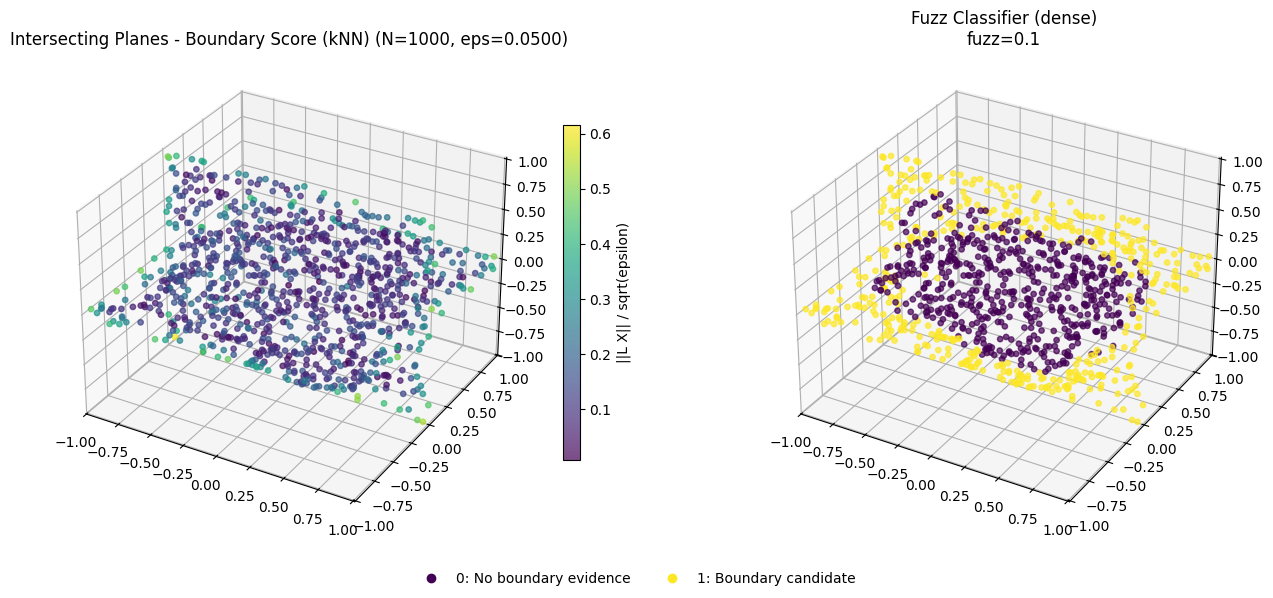

In [8]:
# 7. Intersecting Plane Patches
N = 1000
eps = 0.05
X = mu.sample_plane_intersection(N=N, noise=0.01, angle=90)
L = mu.compute_laplacian_knn(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color_metric, cmap='viridis', s=15, alpha=0.7)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)', shrink=0.7)
ax1.set_title(f"Intersecting Planes - Boundary Score (kNN) (N={len(X)}, eps={eps:.4f})")
set_equal_aspect_3d(ax1, X)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.7)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
set_equal_aspect_3d(ax2, X)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

Fuzz cutoff: 0 boundary candidates out of 500 points.


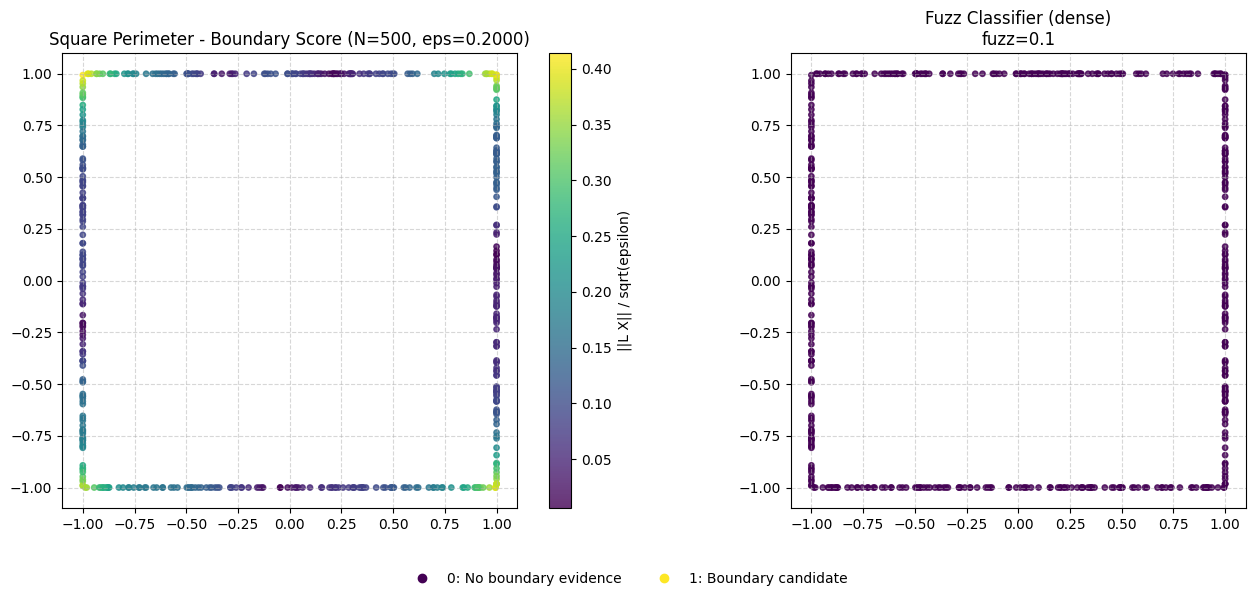

In [9]:
# 8. Square Perimeter
N = 500
eps = .2
X = mu.sample_square(N=N, noise=0.0)
L = mu.compute_laplacian(X, eps)

# Compute boundary indicator metric: ||L X|| / sqrt(eps)
color_metric = np.linalg.norm((L @ X) / np.sqrt(eps), axis=1)

# Classify with the fuzz threshold over the adaptive epsilon grid.
boundary_labels = mu.classify_boundary_threshold(X, fuzz=FUZZ, use_knn=False)
print(f"Fuzz cutoff: {boundary_labels.sum()} boundary candidates out of {len(X)} points.")

fig = plt.figure(figsize=(14, 6))

# Left plot: Boundary score at the displayed epsilon
ax1 = fig.add_subplot(1, 2, 1)
sc1 = ax1.scatter(X[:, 0], X[:, 1], c=color_metric, cmap='viridis', s=15, alpha=0.8)
fig.colorbar(sc1, ax=ax1, label='||L X|| / sqrt(epsilon)')
ax1.set_title(f"Square Perimeter - Boundary Score (N={len(X)}, eps={eps:.4f})")
ax1.set_aspect('equal')
ax1.grid(True, linestyle='--', alpha=0.5)

# Right plot: Fuzz classifier
ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(X[:, 0], X[:, 1], c=boundary_labels, cmap='viridis', vmin=0, vmax=1, s=15, alpha=0.8)
ax2.set_title(f"Fuzz Classifier (dense)\nfuzz={FUZZ:g}")
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', alpha=0.5)

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(0.0),
           label='0: No boundary evidence'),
    Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(1.0),
           label='1: Boundary candidate'),
], loc='lower center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

## Boundary Detection on MNIST

Use the fuzz classifier on the selected digit images in their original pixel space. All classifications below use the positive FUZZ setting from the first cell (default 0.1). The image grids and t-SNE plot show the same cutoff labels.

A large number of detections is not evidence that all those images are manifold boundaries. Suitable bandwidths and the image-space metric remain open issues for this application; the README describes mathematically motivated improvements to investigate.


In [10]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import manifold_utils as mu

# Load MNIST (full 28x28 resolution)
print("Downloading MNIST (this may take a moment)...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')

In [77]:
from sklearn.decomposition import PCA

# Convert labels and pixel data to NumPy arrays
target = mnist.target.astype(int).values
data = mnist.data.values

# Select images of digit '5'
mask = target == 9
X_flat = data[mask]
X_images = X_flat.reshape(-1, 28, 28)

# Apply PCA and overwrite X_flat with the PCA representation
pca = PCA(n_components=50)
X_flat = pca.fit_transform(X_flat)

print(X_flat.shape)

(6958, 50)


In [78]:
# Use the same positive-fuzz classifier as the synthetic examples.
boundary_labels = mu.classify_boundary_threshold(
    X_flat, use_knn=True, k=8, fuzz=.1
)
idx_boundary = np.where(boundary_labels == 1)[0]
idx_interior = np.where(boundary_labels == 0)[0]
print(f"Fuzz={FUZZ:g}: {len(idx_boundary)} boundary candidates and "
      f"{len(idx_interior)} images with no boundary evidence.")


Fuzz=0.1: 1910 boundary candidates and 5048 images with no boundary evidence.


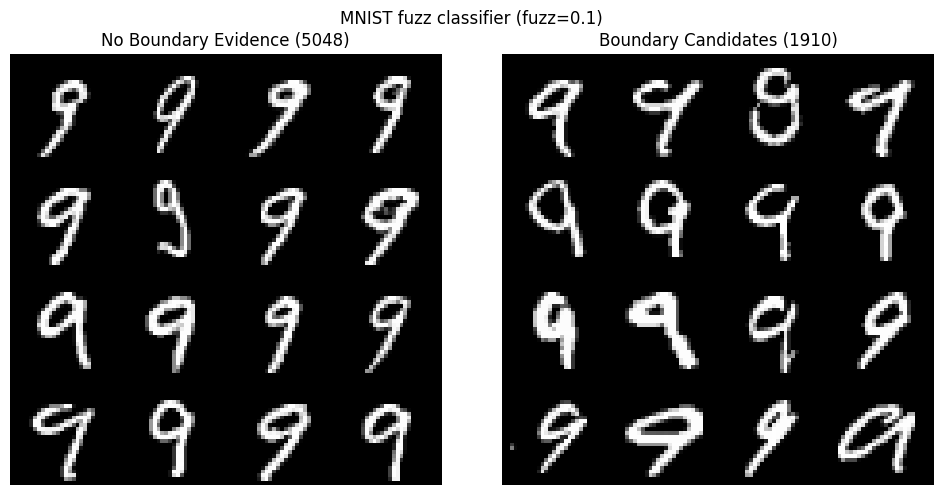

In [79]:
def plot_image_grid(images, title, ax, max_images=16):
    n = min(len(images), max_images)
    if n == 0:
        ax.set_title(f"No images for {title}")
        ax.axis("off")
        return

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    # Create one large image by tiling the small images
    h, w = images[0].shape
    grid = np.zeros((rows * h, cols * w))

    for i in range(n):
        r, c = divmod(i, cols)
        grid[r*h:(r+1)*h, c*w:(c+1)*w] = images[i]

    ax.imshow(grid, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

# Show images selected and not selected by the fuzz classifier.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_image_grid(X_images[idx_interior],
                f"No Boundary Evidence ({len(idx_interior)})", axes[0])
plot_image_grid(X_images[idx_boundary],
                f"Boundary Candidates ({len(idx_boundary)})", axes[1])
fig.suptitle(f"MNIST fuzz classifier (fuzz={FUZZ:g})")
plt.tight_layout()
plt.show()


### t-SNE visualization

Red marks the fuzz classifier's candidates in an embedding of the original pixel-space data. t-SNE is for visualization; its apparent edges do not define manifold boundaries.


Computing t-SNE embedding...


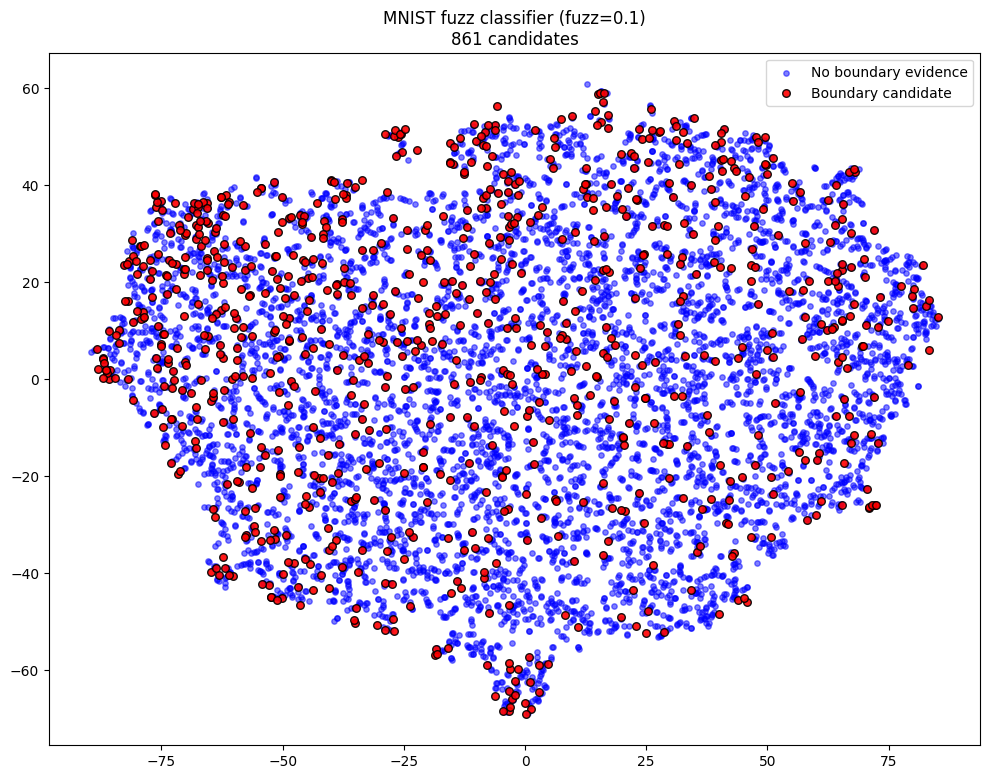

In [76]:
print("Computing t-SNE embedding...")
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(10, 8))
selected = boundary_labels == 1
ax.scatter(X_tsne[~selected, 0], X_tsne[~selected, 1],
           c="blue", alpha=0.5, label="No boundary evidence", s=15)
ax.scatter(X_tsne[selected, 0], X_tsne[selected, 1],
           c="red", alpha=0.9, label="Boundary candidate", s=30, edgecolor="k")
ax.set_title(f"MNIST fuzz classifier (fuzz={FUZZ:g})\n{selected.sum()} candidates")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Boundary Detection on Rotated Image Manifold

Here we create a 1D manifold by taking a single reference image and rotating it from -90 degrees to +90 degrees. The algorithm should identify the images at the two extreme angles as the boundaries of this manifold.

In [40]:
from scipy.ndimage import rotate

# Take a reference image (e.g. a full resolution digit '3')
ref_image = data[target == 3][0].reshape(28, 28)

# Generate rotated images from -90 to 90 degrees
angles = np.linspace(-90, 90, 61)
rotated_images = []
for angle in angles:
    # Rotate using spline interpolation, keeping the original image dimensions
    rot_img = rotate(ref_image, angle, reshape=False)
    rotated_images.append(rot_img)

rotated_images = np.array(rotated_images)
X_rot_flat = rotated_images.reshape(len(angles), -1)

print(f"Generated {len(angles)} rotated images.")

# Classify the rotated images with the fuzz threshold.
boundary_labels_rot = mu.classify_boundary_threshold(
    X_rot_flat, use_knn=False, fuzz=0
)
boundary_angles = angles[boundary_labels_rot == 1]
print(f"Fuzz={FUZZ:g}: angles classified as boundary candidates: {boundary_angles}")


Generated 61 rotated images.
Fuzz=0.1: angles classified as boundary candidates: [-90. -87. -84. -81.  81.  84.  87.  90.]


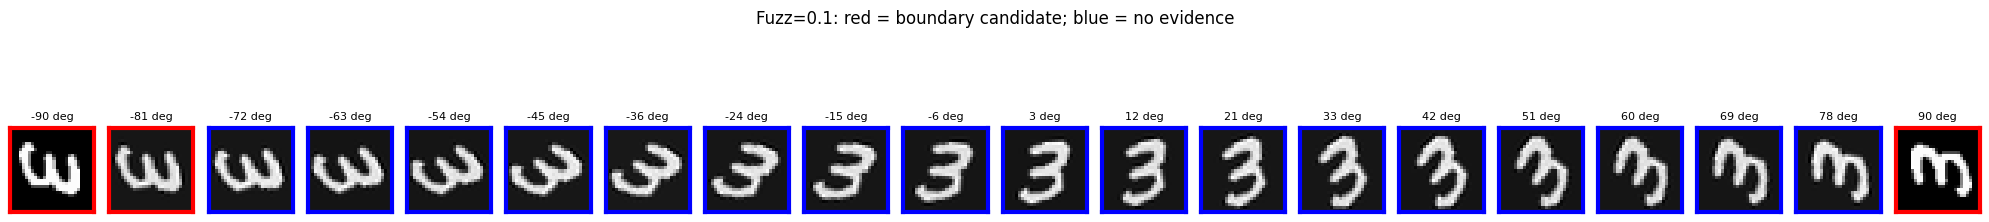

In [41]:
# Mark fuzz detections on a sample of the rotation sequence.
num_to_plot = min(len(angles), 20)
indices_to_plot = np.linspace(0, len(angles) - 1, num_to_plot).astype(int)
fig, axes = plt.subplots(1, num_to_plot, figsize=(20, 3), squeeze=False)
for col, i in enumerate(indices_to_plot):
    ax = axes[0, col]
    ax.imshow(rotated_images[i], cmap="gray")
    color = "red" if boundary_labels_rot[i] == 1 else "blue"
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{angles[i]:.0f} deg", fontsize=8)
fig.suptitle(f"Fuzz={FUZZ:g}: red = boundary candidate; blue = no evidence")
plt.tight_layout()
plt.show()


## Experiment: Pose Estimation Manifold

In pose estimation, the physical limits of a robot's or human's joints create natural boundaries in the state space. Here, we simulate a simple 2-link robotic arm with joint limits. The arm's state is uniquely determined by two angles ($\theta_1$, $\theta_2$). We embed this into a 4D observation space by taking the $(x, y)$ coordinates of both joints.

By running our boundary detection on the 4D point cloud, we can verify if it correctly identifies the physical joint limits of the arm without knowing the underlying angles.

Pose data shape: (1000, 4)
Fuzz=0.1: 220 boundary candidates out of 1000 poses.


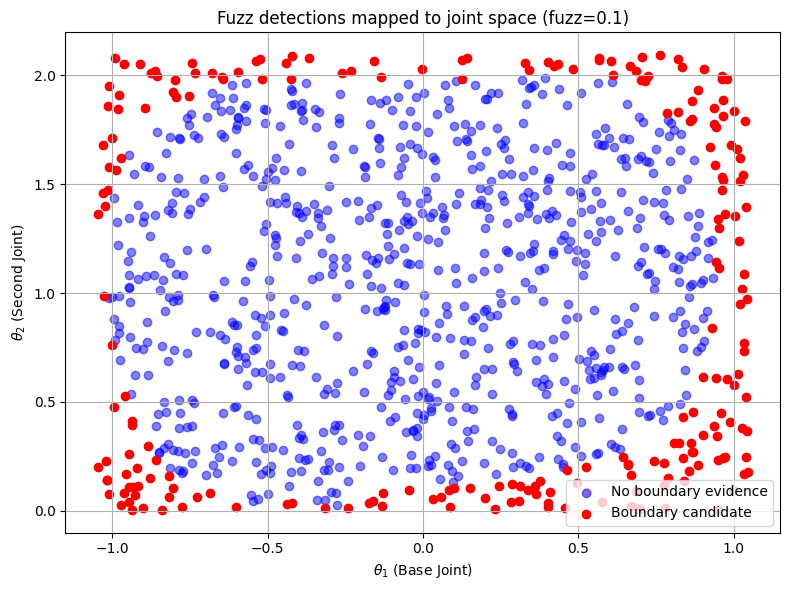

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import manifold_utils as mu

N_pose = 1000
# Joint limits: theta1 in [-pi/3, pi/3], theta2 in [0, 2*pi/3]
theta1 = np.random.uniform(-np.pi/3, np.pi/3, N_pose)
theta2 = np.random.uniform(0, 2*np.pi/3, N_pose)

# Forward kinematics to 4D observation space (x1, y1, x2, y2)
L1, L2 = 1.0, 1.0
x1 = L1 * np.cos(theta1)
y1 = L1 * np.sin(theta1)
x2 = x1 + L2 * np.cos(theta1 + theta2)
y2 = y1 + L2 * np.sin(theta1 + theta2)

X_pose = np.column_stack((x1, y1, x2, y2))
print(f"Pose data shape: {X_pose.shape}")

# Apply the fuzz classifier in the four-dimensional observation space.
boundary_labels_pose = mu.classify_boundary_threshold(
    X_pose, use_knn=False, fuzz=FUZZ
)
selected = boundary_labels_pose == 1
print(f"Fuzz={FUZZ:g}: {selected.sum()} boundary candidates out of {N_pose} poses.")

# Use joint coordinates only to inspect where the detections occurred.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(theta1[~selected], theta2[~selected], c="blue", alpha=0.5,
           label="No boundary evidence")
ax.scatter(theta1[selected], theta2[selected], c="red", label="Boundary candidate")
ax.set_xlabel(r"$\theta_1$ (Base Joint)")
ax.set_ylabel(r"$\theta_2$ (Second Joint)")
ax.set_title(f"Fuzz detections mapped to joint space (fuzz={FUZZ:g})")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
